## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, SONFIS, EarlyStopping, get_measures, Gaussian_MF

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Surface (10k)

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 32, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 32, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [7]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced= True
)

In [8]:
model.init_premises(x_train)

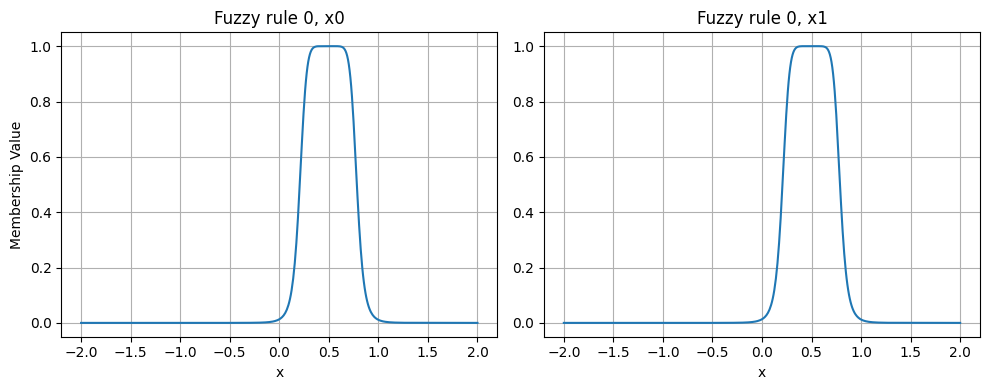

In [9]:
model.plot_premises()

### Hybrid Learning Algorithm

In [18]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [11]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [12]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [13]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [14]:
%time sonfis(model, train_loader, verbose=True)

 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 2.975561 - validation loss: 2.946296
 -> Fuzzy rules: 4

Iteration:  2/40 - loss: 1.640318 - validation loss: 1.702928
 -> Fuzzy rules: 7

Iteration:  3/40 - loss: 1.310598 - validation loss: 1.367598
 -> Fuzzy rules: 10

Iteration:  4/40 - loss: 0.618798 - validation loss: 0.646684
 -> Fuzzy rules: 13

Iteration:  5/40 - loss: 0.450721 - validation loss: 0.427726
 -> Fuzzy rules: 16

Iteration:  6/40 - loss: 0.398559 - validation loss: 0.377149
 -> Fuzzy rules: 16

Iteration:  7/40 - loss: 0.324998 - validation loss: 0.300467
 -> Fuzzy rules: 17

Iteration:  8/40 - loss: 0.279534 - validation loss: 0.252526
 -> Fuzzy rules: 17

Iteration:  9/40 - loss: 0.280153 - validation loss: 0.252431
 -> Fuzzy rules: 19

Iteration: 10/40 - loss: 0.283609 - validation loss: 0.257555
 -> Fuzzy rules: 19

Iteration: 11/40 - loss: 0.202465 - validation loss: 0.222911
 -> Fuzzy rules: 20

Iteration: 12/40 - loss: 0.207745 - validation loss: 0.226340
 -> Fuz

In [15]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.013375429152856756
RMSE: 0.11565219043691631
MAE: 0.0804445911421546
R2: 0.9962936085429455
MAPE: 8.40109082555833


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.022149266227196124
RMSE: 0.14882629548300974
MAE: 0.11455100542086666
R2: 0.9939343990673158
MAPE: 13.235781017405898


# Surface (1k)

In [30]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.1,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [31]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [32]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 16, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [33]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced = False
)

In [34]:
model.init_premises(x_train)

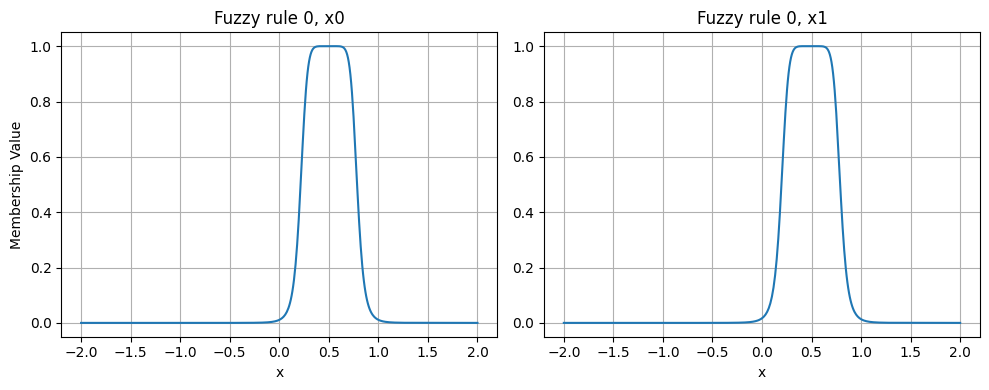

In [35]:
model.plot_premises()

### Hybrid Learning Algorithm

In [36]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [37]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [38]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [39]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [40]:
%time sonfis(model, train_loader, verbose=True)

 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 2.057436 - validation loss: 1.857038
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 1.244744 - validation loss: 1.182447
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 1.153093 - validation loss: 1.212703
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.976072 - validation loss: 0.983458
 -> Fuzzy rules: 6

Iteration:  5/40 - loss: 1.031604 - validation loss: 0.983495
 -> Fuzzy rules: 7

Iteration:  6/40 - loss: 1.037872 - validation loss: 0.988627
 -> Fuzzy rules: 8

Iteration:  7/40 - loss: 1.037442 - validation loss: 0.980323
 -> Fuzzy rules: 9

Iteration:  8/40 - loss: 1.037942 - validation loss: 0.980184
 -> Fuzzy rules: 10

Early stopping

Training finished
 -> Fuzzy rules: 5

CPU times: user 1min 35s, sys: 649 ms, total: 1min 35s
Wall time: 52.7 s


In [41]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.03256901277937234
RMSE: 0.18046886928047268
MAE: 0.12073287463123936
R2: 0.9896146700363851
MAPE: 5.5019324729044765


In [42]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.03502114973977676
RMSE: 0.18713938585924866
MAE: 0.1374948171615782
R2: 0.990776457970233
MAPE: 1.7586191388753523


# Synt 1

## Data

In [4]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [15]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [7]:
model = ANFIS(
    input_size = 3,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [8]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [9]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [10]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [11]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [12]:
%time sonfis(model, loader, verbose=True)

 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 0.016527 - validation loss: 0.013580
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 0.253293 - validation loss: 0.196917
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 0.043221 - validation loss: 0.040799
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.047850 - validation loss: 0.046902
 -> Fuzzy rules: 5

Iteration:  5/40 - loss: 0.035158 - validation loss: 0.034514
 -> Fuzzy rules: 4

Early stopping

Training finished
 -> Fuzzy rules: 2

CPU times: user 13.4 s, sys: 185 ms, total: 13.6 s
Wall time: 3.6 s


In [13]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.004820428609382115
RMSE: 0.0694293065598535
MAE: 0.057925329422249955
R2: 0.996658336843242
MAPE: 0.008990671564018705


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.010733421467129642
RMSE: 0.10360222713402276
MAE: 0.08209148882497785
R2: 0.9948794216822254
MAPE: 0.012496153205849705


# Synt 2

## Data

In [147]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [148]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [149]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [150]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [151]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True,
    membership_function=Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [152]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [153]:
trainer = Hybrid_learning_algorithm(
    epochs=10,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [154]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=7, delta=0.01)
last_training_iteration = True

In [155]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [156]:
%time sonfis(model, loader, verbose=True)

 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 1.686677 - validation loss: 1.597754
 -> Fuzzy rules: 4

Iteration:  2/40 - loss: 1.768689 - validation loss: 1.885511
 -> Fuzzy rules: 6

Iteration:  3/40 - loss: 1.592905 - validation loss: 1.806712
 -> Fuzzy rules: 7

Iteration:  4/40 - loss: 1.278631 - validation loss: 1.446733
 -> Fuzzy rules: 5

Iteration:  5/40 - loss: 8.925074 - validation loss: 8.053821
 -> Fuzzy rules: 7

Iteration:  6/40 - loss: 3.281939 - validation loss: 4.573139
 -> Fuzzy rules: 8

Iteration:  7/40 - loss: 2.985075 - validation loss: 4.188515
 -> Fuzzy rules: 8

Iteration:  8/40 - loss: 3.595482 - validation loss: 4.550074
 -> Fuzzy rules: 8

Iteration:  9/40 - loss: 0.748649 - validation loss: 1.156807
 -> Fuzzy rules: 8

Iteration: 10/40 - loss: 0.148059 - validation loss: 0.161794
 -> Fuzzy rules: 8

Iteration: 11/40 - loss: 0.110954 - validation loss: 0.136313
 -> Fuzzy rules: 6

Iteration: 12/40 - loss: 0.218153 - validation loss: 0.341419
 -> Fuzzy rules:

In [157]:
model.fuzzy_rules

7

In [158]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.0016887912361205942
RMSE: 0.04109490523313802
MAE: 0.030686095278256362
R2: 0.972671150287402
MAPE: 1.6387744344961792


In [159]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0018110752362532347
RMSE: 0.042556729623565236
MAE: 0.034997725991006534
R2: 0.9712354566790328
MAPE: 0.7448124105726971
